$$\def\data{ {\bf d}_\rm{obs}}
\def\vec{\bf}
\def\m{ {\bf m}}
\def\map{{\bf m}_{\text{MAP}}}
\def\postcov{{\bf \Gamma}_{\text{post}}}
\def\prcov{{\bf \Gamma}_{\text{prior}}}
\def\matrix{\bf}
\def\Hmisfit{{\bf H}_{\text{misfit}}}
\def\diag{\operatorname{diag}}
\def\Vr{{\matrix V}_r}
\def\Ir{{\matrix I}_r}
\def\H{{\matrix H} }
$$
# Bayesian quantification of parameter uncertainty
## Estimating the Gaussian approximation of the posterior pdf of the coefficient parameter field in an elliptic PDE

In this example we tackle the problem of quantifying the uncertainty in the solution of an
inverse problem governed by an elliptic PDE via the Bayesian inference framework. Hence,
we state the inverse problem as a problem of statistical inference over the space of
uncertain parameters, which are to be inferred from data and a physical model. The
resulting solution to the statistical inverse problem is a posterior distribution that
assigns to any candidate set of parameter fields our belief (expressed as a probability)
that a member of this candidate set is the "true" parameter field that gave rise to the
observed data.

For simplicity, in what follows we give finite-dimensional expressions (i.e., after
discretization of the parameter space) for the Bayesian formulation of the inverse
problem.

### Bayes' Theorem:

The posterior probability distribution combines the prior pdf $\pi_{\text{prior}}(\m)$ over
the parameter space, which encodes any knowledge or assumptions about the parameter space
that we may wish to impose before the data are considered, with a likelihood pdf
$\pi_{\text{like}}(\data \; | \; \m)$, which explicitly represents the probability that a
given set of parameters $\m$ might give rise to the observed data $\data \in \mathbb{R}^q$,
namely:

$$ \pi_{\text{post}}(\m | \data) \propto \pi_{\text{prior}}(\m) \pi_{\text{like}}(\data | \m). $$

Note that the infinite-dimensional analog of Bayes' formula requires the use of
Radon-Nikodym derivatives instead of probability density functions.

### Gaussian prior and noise:

#### The prior:

We consider a Gaussian prior with mean ${\vec m}_{\text{prior}}$ and covariance $\prcov$.
The covariance is given by the discretization of the inverse of the differential operator
$\mathcal{A}^{-2} = (-\gamma \Delta + \delta I)^{-2}$, where $\gamma$, $\delta > 0$ control
the correlation length and the variance of the prior. This choice of prior ensures that
it is a trace-class operator, guaranteeing bounded pointwise variance and a well-posed
infinite-dimensional Bayesian inverse problem.

#### The likelihood:

$$ \data = {\bf f}(\m) + {\bf e }, \;\;\; {\bf e} \sim \mathcal{N}({\bf 0}, {\bf \Gamma}_{\text{noise}} ) $$

$$ \pi_{\text{like}}(\data \; | \; \m) = \exp \left( - \tfrac{1}{2} ({\bf f}(\m) - \data)^T {\bf \Gamma}_{\text{noise}}^{-1} ({\bf f}(\m) - \data)\right) $$

Here ${\bf f}$ is the parameter-to-observable map that takes a parameter vector $\m$ and
maps it to the space of the observation vector $\data$.

#### The posterior:

$$ \pi_{\text{post}}(\m \; | \; \data) \propto \exp \left( - \tfrac{1}{2} \parallel {\bf f}(\m) - \data \parallel^{2}_{{\bf \Gamma}_{\text{noise}}^{-1}} \! - \tfrac{1}{2}\parallel \m - \m_{\rm prior} \parallel^{2}_{\prcov^{-1}} \right) $$

### The Laplace approximation to the posterior: $\mathcal{N}({\vec \map},\bf \postcov)$

The mean of this posterior distribution, ${\vec \map}$, is the parameter vector maximizing
the posterior, and is known as the maximum a posteriori (MAP) point. It can be found by
minimizing the negative log of the posterior, which amounts to solving a deterministic
inverse problem with appropriately weighted norms,

$$ \map := \underset{\m}{\arg \min} \; \mathcal{J}(\m) \;:=\; \Big( \frac{1}{2} \| {\bf f}(\m) - \data \|^2_{ {\bf \Gamma}_{\text{noise}}^{-1}} + \frac{1}{2} \| \m -\m_{\rm prior} \|^2_{\prcov^{-1}} \Big). $$

The posterior covariance matrix is then given by the inverse of the Hessian matrix of
$\mathcal{J}$ at $\map$, namely

$$ \postcov = \left(\Hmisfit(\map) + \prcov^{-1} \right)^{-1}. $$

#### The generalized eigenvalue problem:

$$ \Hmisfit {\matrix V} = \prcov^{-1} {\matrix V} {\matrix \Lambda}, $$

where ${\matrix \Lambda} = \diag(\lambda_i) \in \mathbb{R}^{n\times n}$ contains the
generalized eigenvalues and the columns of ${\matrix V}\in \mathbb R^{n\times n}$ the
generalized eigenvectors such that ${\matrix V}^T \prcov^{-1} {\matrix V} = {\matrix I}$.

#### Randomized eigensolvers to construct the approximate spectral decomposition:

When the generalized eigenvalues $\{\lambda_i\}$ decay rapidly, we can extract a low-rank
approximation of $\Hmisfit$ by retaining only the $r$ largest eigenvalues and corresponding
eigenvectors,

$$ \Hmisfit \approx \prcov^{-1} \Vr {\matrix{\Lambda}}_r \Vr^T \prcov^{-1}. $$

Here, $\Vr \in \mathbb{R}^{n\times r}$ contains only the $r$ generalized eigenvectors of
$\Hmisfit$ that correspond to the $r$ largest eigenvalues, which are assembled into the
diagonal matrix ${\matrix{\Lambda}}_r = \diag (\lambda_i) \in \mathbb{R}^{r \times r}$.

#### The approximate posterior covariance:

Using the Sherman–Morrison–Woodbury formula, we write

$$ \postcov = \left(\Hmisfit+ \prcov^{-1}\right)^{-1} = \prcov-\Vr {\matrix{D}}_r \Vr^T + \mathcal{O}\left(\sum_{i=r+1}^{n} \frac{\lambda_i}{\lambda_i + 1}\right), $$

where ${\matrix{D}}_r :=\diag(\lambda_i/(\lambda_i+1)) \in \mathbb{R}^{r\times r}$. The
last term in this expression captures the error due to truncation in terms of the
discarded eigenvalues; this provides a criterion for truncating the spectrum, namely that
$r$ is chosen such that $\lambda_r$ is small relative to 1.

Therefore we can approximate the posterior covariance as

$$ \postcov \approx \prcov - \Vr {\matrix{D}}_r \Vr^T. $$

#### Drawing samples from a Gaussian distribution with covariance $\H^{-1}$

Let ${\bf x}$ be a sample from the prior distribution, i.e. ${\bf x} \sim \mathcal{N}({\bf 0}, \prcov)$;
then, using the low-rank approximation of the posterior covariance, we compute a sample
${\bf v} \sim \mathcal{N}({\bf 0}, \H^{-1})$ as

$$ {\bf v} = \big\{ \Vr \big[ ({\matrix{\Lambda}}_r + \Ir)^{-1/2} - \Ir \big] \Vr^T\prcov^{-1} + {\bf I} \big\} {\bf x}. $$

## This tutorial shows:

- Description of the inverse problem (the forward problem, the prior, and the misfit functional)
- Convergence of the inexact Newton-CG algorithm
- Low-rank-based approximation of the posterior covariance (built on a low-rank approximation of the Hessian of the data misfit)
- How to construct the low-rank approximation of the Hessian of the data misfit
- How to apply the inverse and square-root inverse Hessian to a vector efficiently
- Samples from the Gaussian approximation of the posterior

## Goals:

By the end of this notebook, you should be able to:

- Understand the Bayesian inverse framework
- Visualise and understand the results
- Modify the problem and code

## Mathematical tools used:

- Finite element method
- Derivation of gradient and Hessian via the adjoint method
- Inexact Newton-CG
- Armijo line search
- Bayes' formula
- Randomized eigensolvers

## List of software used:

- [MFEM](https://mfem.org) through [PyMFEM](https://github.com/mfem/PyMFEM), a parallel finite element library
- [hypre](https://github.com/hypre-space/hypre), for scalable preconditioners
- [JAX](https://docs.jax.dev), for automatic differentiation
- [Matplotlib](https://matplotlib.org), for plotting the results
- [NumPy](https://numpy.org), for the small dense linear algebra

## 1. Load modules

In [1]:
import math
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb, STATE, PARAMETER, ADJOINT

import jax.numpy as jnp

mfem.Hypre.Init()
comm = MPI.COMM_WORLD

## 2. Generate the true parameter

This function generates a random field with a prescribed anisotropic covariance function:
a sample from the prior defined below. `sample_noise` draws the white noise element by
element from a counter-based generator, so the field is the same on any number of MPI
ranks.

In [2]:
def true_model(prior):
    noise = prior.noise_vector()
    prior.sample_noise(1.0, noise)
    mtrue = prior.mean.duplicate()
    prior.sample(noise, mtrue)
    return mtrue

## 3. Set up the mesh and finite element spaces

We compute a two dimensional mesh of a unit square with nx by ny elements. We define a P2
finite element space for the *state* and *adjoint* variable and P1 for the *parameter*.

In [3]:
nx = ny = 64
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(nx, ny, mfem.Element.TRIANGLE))
Vh2 = hm.FunctionSpace.H1(mesh, 2)
Vh1 = hm.FunctionSpace.H1(mesh, 1)
Vh = [Vh2, Vh1, Vh2]
print("Number of dofs: STATE={0}, PARAMETER={1}, ADJOINT={2}".format(
    Vh[STATE].GlobalTrueVSize(), Vh[PARAMETER].GlobalTrueVSize(), Vh[ADJOINT].GlobalTrueVSize()))

Number of dofs: STATE=16641, PARAMETER=4225, ADJOINT=16641


## 4. Set up the forward problem

To set up the forward problem we use the `PDEVariationalProblem` class, which requires the
following inputs:

- the finite element spaces for the state, parameter, and adjoint variables `Vh`;
- the PDE as a residual density `pde_varf(u, m, p, x)`, evaluated at one quadrature point;
- the boundary conditions `bc` for the forward problem and `bc0` for the adjoint and incremental problems.

The `PDEVariationalProblem` class offers the following functionality:

- solving the forward/adjoint and incremental problems;
- evaluating first and second partial derivatives of the forward problem with respect to the state, parameter, and adjoint variables, all generated from `pde_varf` by automatic differentiation.

The state is prescribed on the top and bottom edges ($u = y$ there) and the left and right
edges are insulated.

In [4]:
bottom, right, top, left = 1, 2, 3, 4
bc = hm.DirichletBC(Vh[STATE], lambda x: x[1], bdr_attributes=[bottom, top])
bc0 = bc.homogeneous()

f = 0.0


def pde_varf(u, m, p, x):
    return jnp.exp(m.val) * hm.inner(u.grad, p.grad) - f * p.val


pde = hm.PDEVariationalProblem(Vh, pde_varf, bc, bc0, is_fwd_linear=True)

## 5. Set up the prior

To obtain the synthetic true parameter $m_{\rm true}$ we generate a realization from the
prior distribution. Here we assume a Gaussian prior with zero average and covariance
matrix $\mathcal{C} = \mathcal{A}^{-2}$. The action of $\mathcal{A}$ on a field $m$ is
given by

$$ \mathcal{A}m =
\left\{
\begin{array}{rl}
-\gamma \nabla \cdot \left( \Theta\nabla m\right)+ \delta m & \text{in } \Omega\\
\gamma \left( \Theta\, \nabla m\right) \cdot \boldsymbol{n} + \beta m & \text{on } \partial\Omega,
\end{array}
\right.
$$

where $\beta \propto \sqrt{\gamma\delta}$ is chosen to minimize boundary artifacts (the
`robin_bc=True` option). Here $\Theta$ is a symmetric positive definite anisotropic tensor
of the form

$$ \Theta =
\begin{bmatrix}
\theta_1 \sin^2\alpha + \theta_2 \cos^2\alpha & (\theta_1-\theta_2) \sin\alpha \cos\alpha \\
(\theta_1-\theta_2) \sin\alpha \cos\alpha & \theta_1 \cos^2\alpha + \theta_2 \sin^2\alpha
\end{bmatrix}. $$

Prior regularization: (delta - gamma*Laplacian)^order: delta=0.5, gamma=0.1, order=2


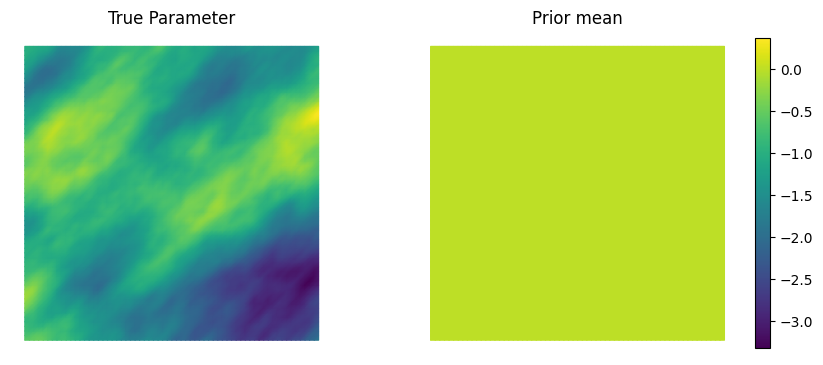

In [5]:
gamma = 0.1
delta = 0.5

theta0 = 2.0
theta1 = 0.5
alpha = math.pi / 4
sa, ca = math.sin(alpha), math.cos(alpha)
Theta = np.array([[theta0 * sa**2 + theta1 * ca**2, (theta0 - theta1) * sa * ca],
                  [(theta0 - theta1) * sa * ca, theta0 * ca**2 + theta1 * sa**2]])

prior = hm.BiLaplacianPrior(Vh[PARAMETER], gamma, delta, Theta=Theta, robin_bc=True)
hm.parRandom.set_seed(1)
mtrue = true_model(prior)

print("Prior regularization: (delta - gamma*Laplacian)^order: delta={0}, gamma={1}, order={2}".format(delta, gamma, 2))

nb.multi1_plot([(Vh[PARAMETER], mtrue), (Vh[PARAMETER], prior.mean)], ["True Parameter", "Prior mean"])
plt.show()

## 6. Set up the misfit functional and generate synthetic observations

To set up the observation operator $\mathcal{B}: \mathcal{V} \mapsto \mathbb{R}^{n_t}$, we
generate $n_t$ (`ntargets` in the code below) random locations where to evaluate the value
of the state.

Under the assumption of Gaussian additive noise, the likelihood function $\pi_{\rm like}$
has the form

$$\pi_{\rm like}( \data \,| \, m ) \propto \exp\left( -\frac{1}{2}\|\mathcal{B}\,u(m) - \data \|^2_{\Gamma_{\rm noise}^{-1}}\right), $$

where $u(m)$ denotes the solution of the forward model at a given parameter $m$. The
observation operator $\mathcal{B}$ is built by the function `assemblePointwiseObservation`.

The class `DiscreteStateObservation` implements the evaluation of the log-likelihood
function and of its partial derivatives with respect to the state $u$ and parameter $m$.

To generate the synthetic observations, we first solve the forward problem using the true
parameter $m_{\rm true}$. Synthetic observations are obtained by perturbing the state
variable at the observation points with random Gaussian noise; `rel_noise` is the noise
standard deviation relative to the largest observed value. `B.perturb` keys the noise on
the index of each observation point, so the data are the same on any number of ranks.

Number of observation points: 50


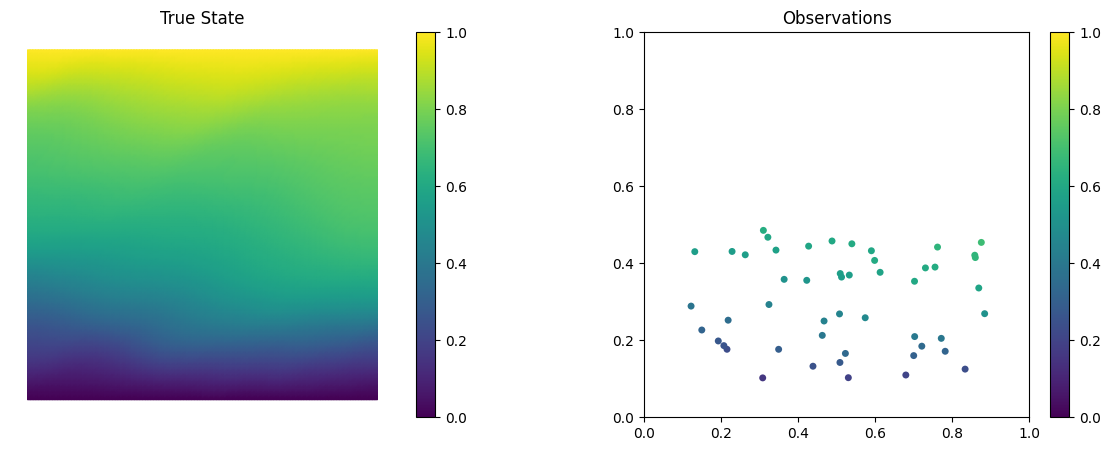

In [6]:
ntargets = 50
rel_noise = 0.01

# targets only on the bottom half of the domain
rng = np.random.default_rng(1)
targets = np.column_stack((rng.uniform(0.1, 0.9, ntargets), rng.uniform(0.1, 0.5, ntargets)))
print("Number of observation points: {0}".format(ntargets))
B = hm.assemblePointwiseObservation(Vh[STATE], targets)

utrue = pde.generate_state()
x = [utrue, mtrue, None]
pde.solveFwd(x[STATE], x)
data = B.createVecLeft()
B.mult(x[STATE], data)
MAX = data.norm("linf")
noise_std_dev = rel_noise * MAX
B.perturb(data, noise_std_dev)
misfit = hm.DiscreteStateObservation(B, data, noise_std_dev**2)

observed = B.gather(data)                  # the data as a numpy array, in target order
vmax = max(utrue.max(), observed.max())
vmin = min(utrue.min(), observed.min())

plt.figure(figsize=(15, 5))
nb.plot(Vh[STATE], utrue, mytitle="True State", subplot_loc=121, vmin=vmin, vmax=vmax)
nb.plot_pts(targets, observed, mytitle="Observations", subplot_loc=122, vmin=vmin, vmax=vmax)
plt.show()

## 7. Set up the model and test gradient and Hessian

The model is defined by three components:

- the `PDEVariationalProblem` `pde`, which provides methods for the solution of the forward problem, adjoint problem, and incremental forward and adjoint problems;
- the `Prior` `prior`, which provides methods to apply the regularization (*precision*) operator to a vector or to apply the prior covariance operator (i.e. to solve linear systems with the regularization operator);
- the `Misfit` `misfit`, which provides methods to compute the cost functional and its partial derivatives with respect to the state and parameter variables.

To test the gradient and the Hessian of the model we use forward finite differences.

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  3.319028e+06  2.572853e+01  3.333498e+06             -


 5.00e-01  1.659496e+06  1.250855e+01  8.443862e+05        1.0000


 2.50e-01  8.297472e+05  6.664491e+00  2.221597e+05        1.0000


 1.25e-01  4.148741e+05  3.431298e+00  6.662445e+04        1.0000


...

 7.45e-09  8.408071e-01  1.850373e-03  1.480748e+04       -1.3512


 3.73e-09  1.777086e+00  4.004995e-03  1.480748e+04       -1.0797


 1.86e-09  2.669176e+00  5.018634e-03  1.480748e+04       -0.5869


 9.31e-10  7.334215e+00  1.552050e-02  1.480748e+04       -1.4582


 4.66e-10  1.457445e+01  3.127710e-02  1.480748e+04       -0.9907


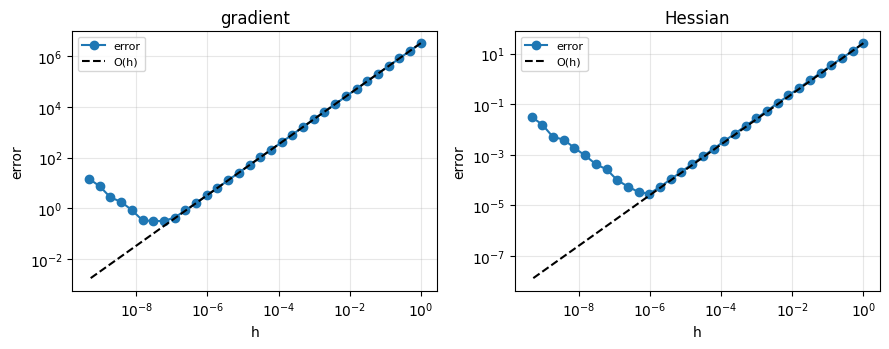

In [7]:
model = hm.Model(pde, prior, misfit)

m0 = Vh[PARAMETER].project(lambda x: np.sin(x[0]))
_ = hm.modelVerify(model, m0, plotting=True)
plt.show()

## 8. Compute the MAP point

We use the globalized Newton-CG method to compute the MAP point.


 It cg_it            cost          misfit             reg          (g,dm)          ||g||          alpha          tolcg


  1     1    1.011064e+03    1.010572e+03    4.916841e-01   -2.747493e+04   6.853449e+04   1.000000e+00   5.000000e-01


  2     2    1.346665e+02    1.339094e+02    7.571320e-01   -1.777904e+03   1.101208e+04   1.000000e+00   4.008483e-01


  3     4    6.476617e+01    6.321515e+01    1.551014e+00   -1.415493e+02   2.712943e+03   1.000000e+00   1.989600e-01


  4     6    2.883538e+01    2.459352e+01    4.241853e+00   -7.407268e+01   1.343462e+03   1.000000e+00   1.400097e-01


...

  7     1    2.325945e+01    1.645224e+01    6.807208e+00   -9.550385e-01   4.677418e+02   1.000000e+00   8.261302e-02


  8    18    2.317059e+01    1.623650e+01    6.934091e+00   -1.775696e-01   8.239075e+01   1.000000e+00   3.467246e-02


  9     6    2.317022e+01    1.623729e+01    6.932936e+00   -7.374701e-04   1.184277e+01   1.000000e+00   1.314535e-02


 10    22    2.317015e+01    1.622739e+01    6.942758e+00   -1.480130e-04   3.625118e+00   1.000000e+00   7.272881e-03



Converged in 10 iterations.
Termination reason: Norm of the gradient less than tolerance
Final gradient norm: 0.01637160440654537
Final cost: 23.1701498621551


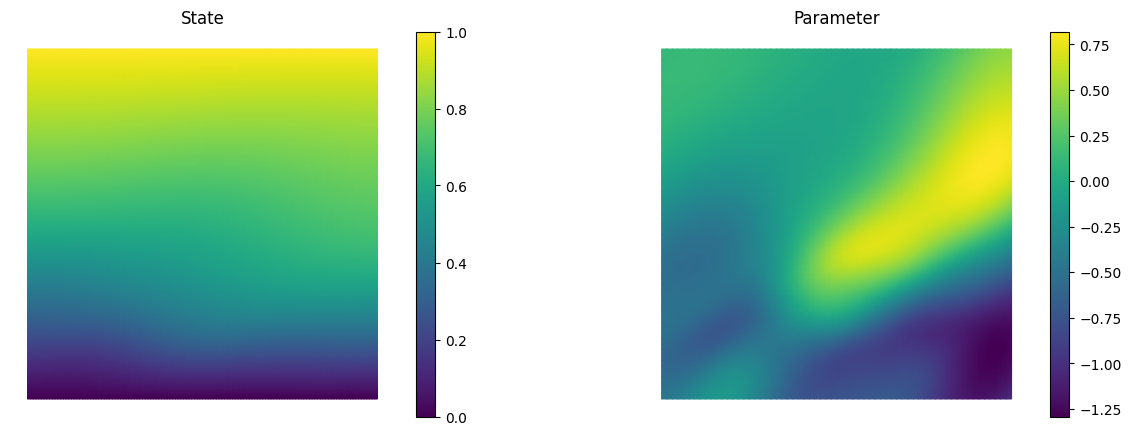

In [8]:
m = prior.mean.copy()
parameters = hm.ReducedSpaceNewtonCG_ParameterList()
parameters["rel_tolerance"] = 1e-6
parameters["abs_tolerance"] = 1e-12
parameters["max_iter"] = 25
parameters["GN_iter"] = 5
parameters["globalization"] = "LS"
parameters["LS"]["c_armijo"] = 1e-4
solver = hm.ReducedSpaceNewtonCG(model, parameters)

x = solver.solve([None, m, None])

if solver.converged:
    print("\nConverged in", solver.it, "iterations.")
else:
    print("\nNot Converged")

print("Termination reason:", solver.termination_reasons[solver.reason])
print("Final gradient norm:", solver.final_grad_norm)
print("Final cost:", solver.final_cost)

plt.figure(figsize=(15, 5))
nb.plot(Vh[STATE], x[STATE], subplot_loc=121, mytitle="State")
nb.plot(Vh[PARAMETER], x[PARAMETER], subplot_loc=122, mytitle="Parameter")
plt.show()

## 9. Compute the low rank-based Laplace approximation of the posterior

We use the *double pass* algorithm to compute a low-rank decomposition of the Hessian
misfit. In particular, we solve

$$ \Hmisfit {\bf v}_i = \lambda_i \prcov^{-1} {\bf v}_i. $$

The figure shows the largest *k* generalized eigenvalues of the Hessian misfit, and some of
the corresponding eigenvectors. The effective rank of the Hessian misfit is the number of
eigenvalues above the red line ($y=1$). The effective rank is independent of the mesh size.

Double Pass Algorithm. Requested eigenvectors: 50; Oversampling 20.


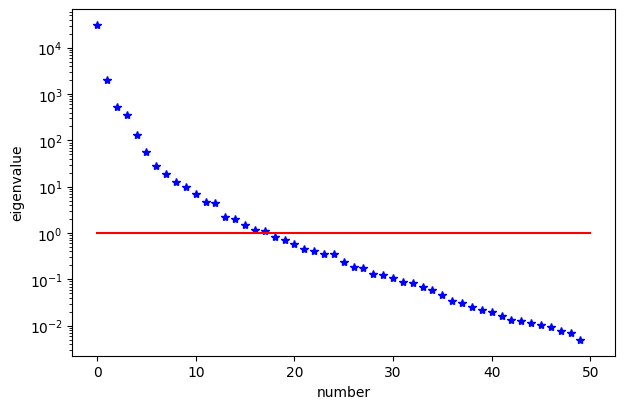

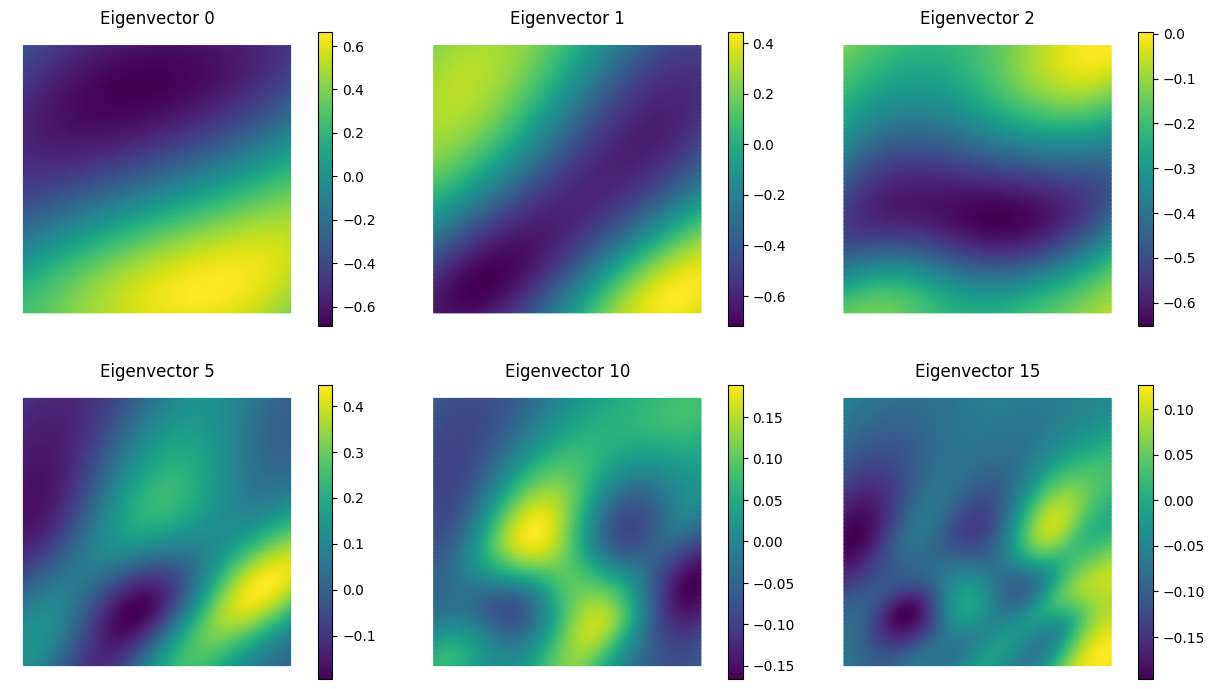

In [9]:
model.setPointForHessianEvaluations(x, gauss_newton_approx=False)
Hmisfit = hm.ReducedHessian(model, misfit_only=True)
k = 50
p = 20
print("Double Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k, p))

Omega = hm.MultiVector(x[PARAMETER], k + p)
hm.parRandom.normal_multivector(1.0, Omega)
lmbda, V = hm.doublePassG(Hmisfit, prior.R, prior.Rsolver, Omega, k)

posterior = hm.GaussianLRPosterior(prior, lmbda, V, mean=x[PARAMETER])

plt.figure(figsize=(7, 4.5))
plt.plot(range(0, k), lmbda, "b*", range(0, k + 1), np.ones(k + 1), "-r")
plt.yscale("log")
plt.xlabel("number")
plt.ylabel("eigenvalue")

nb.plot_eigenvectors(Vh[PARAMETER], V, mytitle="Eigenvector", which=[0, 1, 2, 5, 10, 15])
plt.show()

## 10. Prior and Laplace approximation to posterior pointwise variance fields

The traces and pointwise variances below use hIPPYlib's randomized estimators.

Posterior trace 1.000307e+00; Prior trace 1.797392e+00; Correction trace 7.970847e-01


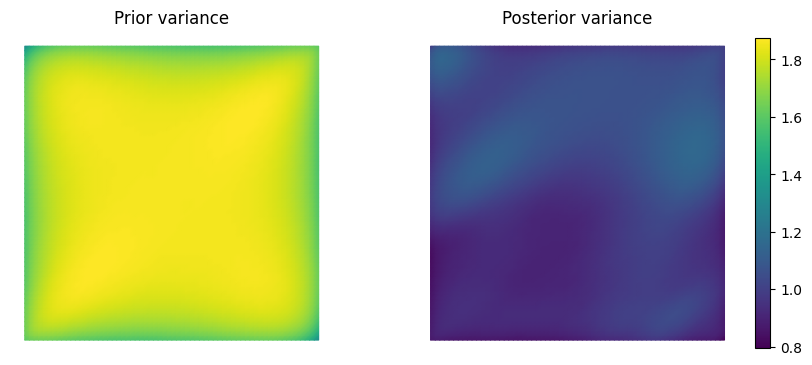

In [10]:
compute_trace = True
if compute_trace:
    post_tr, prior_tr, corr_tr = posterior.trace(method="Randomized", r=200)
    print("Posterior trace {0:5e}; Prior trace {1:5e}; Correction trace {2:5e}".format(post_tr, prior_tr, corr_tr))
post_pw_variance, pr_pw_variance, corr_pw_variance = posterior.pointwise_variance(method="Randomized", r=200)

nb.multi1_plot([(Vh[PARAMETER], pr_pw_variance), (Vh[PARAMETER], post_pw_variance)],
               ["Prior variance", "Posterior variance"], logscale=False)
plt.show()

The randomized pointwise variance is the diagonal of a rank-`r` truncation of the prior
covariance, so it can only underestimate the variance. On a mesh this size the exact prior
variance is affordable (two solves per degree of freedom), and it shows that with `r = 200`
the estimate is within about one percent here. Shorter correlation lengths and finer
meshes need more directions; `method="MonteCarlo"` is the unbiased alternative when the
exact variance is not affordable.

In [11]:
exact_prior_variance = prior.pointwise_variance(method="Exact")
print("randomized estimate / exact prior variance: %.2f on average, %.2f to %.2f pointwise"
      % (pr_pw_variance.sum() / exact_prior_variance.sum(),
         np.min(pr_pw_variance.array / exact_prior_variance.array),
         np.max(pr_pw_variance.array / exact_prior_variance.array)))

randomized estimate / exact prior variance: 1.00 on average, 0.99 to 1.00 pointwise


## 11. Generate samples from the prior and the Laplace approximation to the posterior

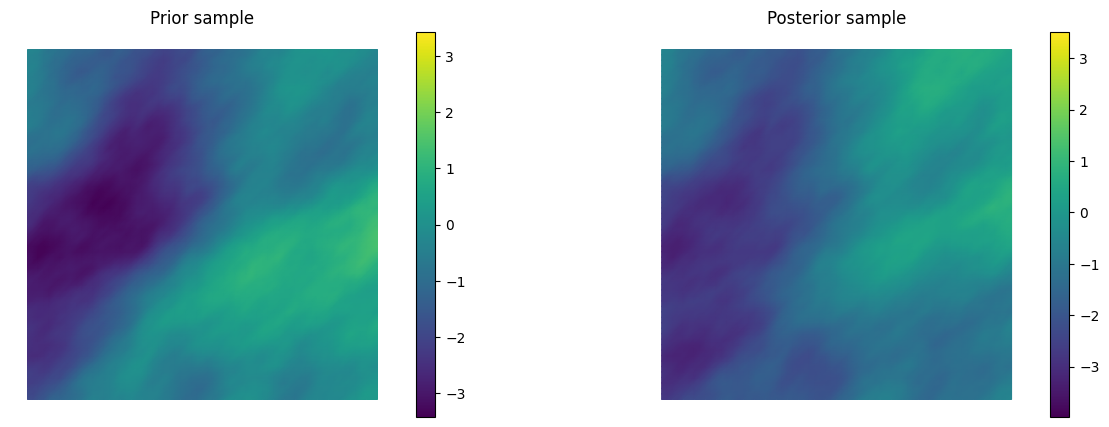

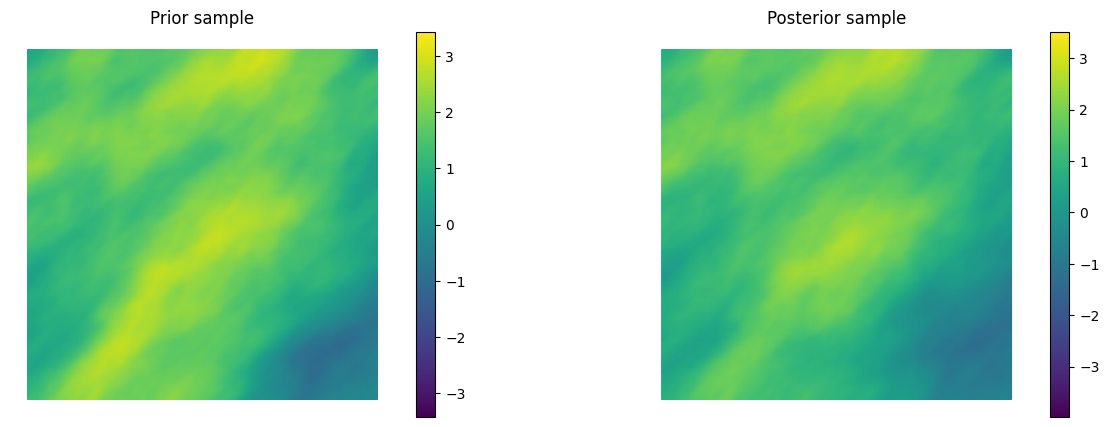

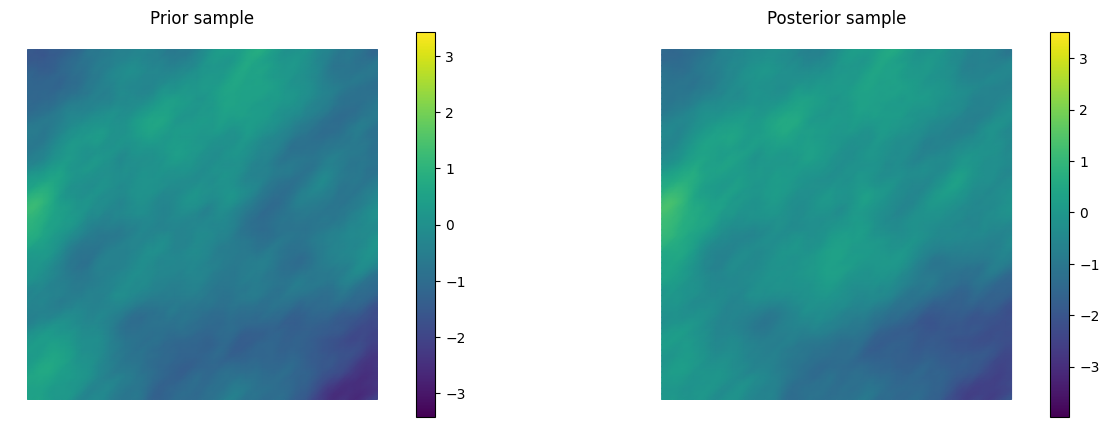

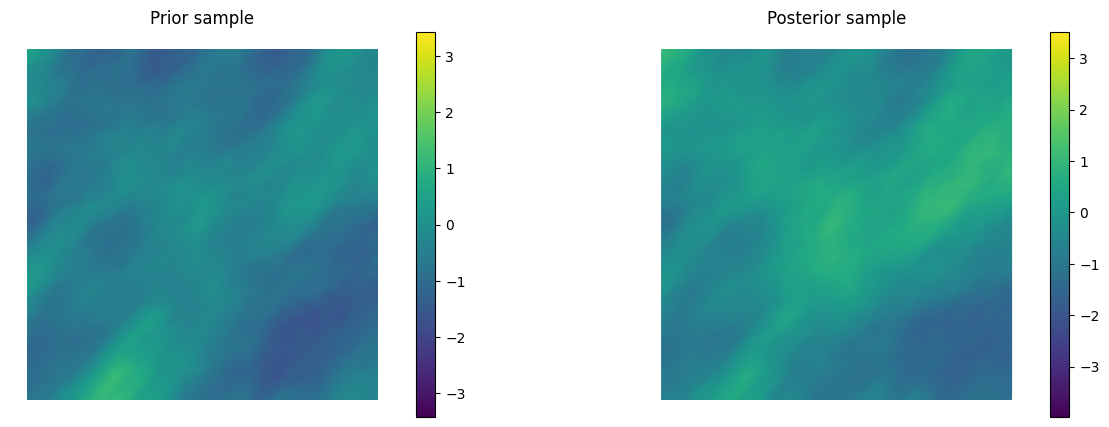

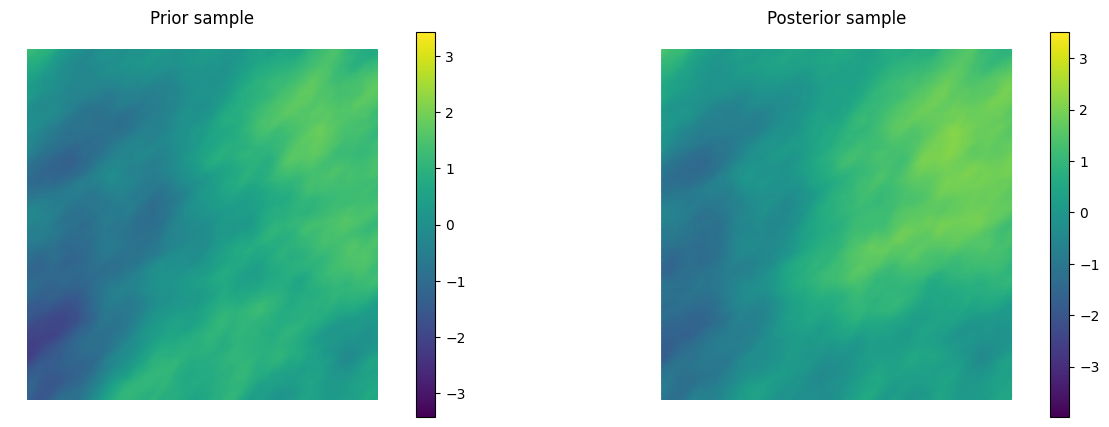

In [12]:
nsamples = 5
noise = prior.noise_vector()
s_prior = Vh[PARAMETER].vector()
s_post = Vh[PARAMETER].vector()

pr_max = 2.5 * math.sqrt(pr_pw_variance.max()) + prior.mean.max()
pr_min = -2.5 * math.sqrt(pr_pw_variance.max()) + prior.mean.min()
ps_max = 2.5 * math.sqrt(post_pw_variance.max()) + posterior.mean.max()
ps_min = -2.5 * math.sqrt(post_pw_variance.max()) + posterior.mean.min()

for i in range(nsamples):
    prior.sample_noise(1.0, noise)
    posterior.sample(noise, s_prior, s_post)
    plt.figure(figsize=(15, 5))
    nb.plot(Vh[PARAMETER], s_prior, subplot_loc=121, mytitle="Prior sample", vmin=pr_min, vmax=pr_max)
    nb.plot(Vh[PARAMETER], s_post, subplot_loc=122, mytitle="Posterior sample", vmin=ps_min, vmax=ps_max)
    plt.show()

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `03_SubsurfaceBayesian`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).